In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# 1. Load data
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')

In [4]:
df.head()

,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135


In [5]:
# 2. Setup Features and Target
X = df[['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']]
y = df['strength_MPa']

In [6]:
# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 4. Train Decision Tree Model
# max_depth controls the complexity of the tree
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [10]:
# 5. Predict and Evaluate
y_pred = dt_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} MPa")
print(f"RMSE: {rmse:.2f} MPa")


R2 Score: 0.9202
MAE: 33.19 MPa
RMSE: 40.86 MPa


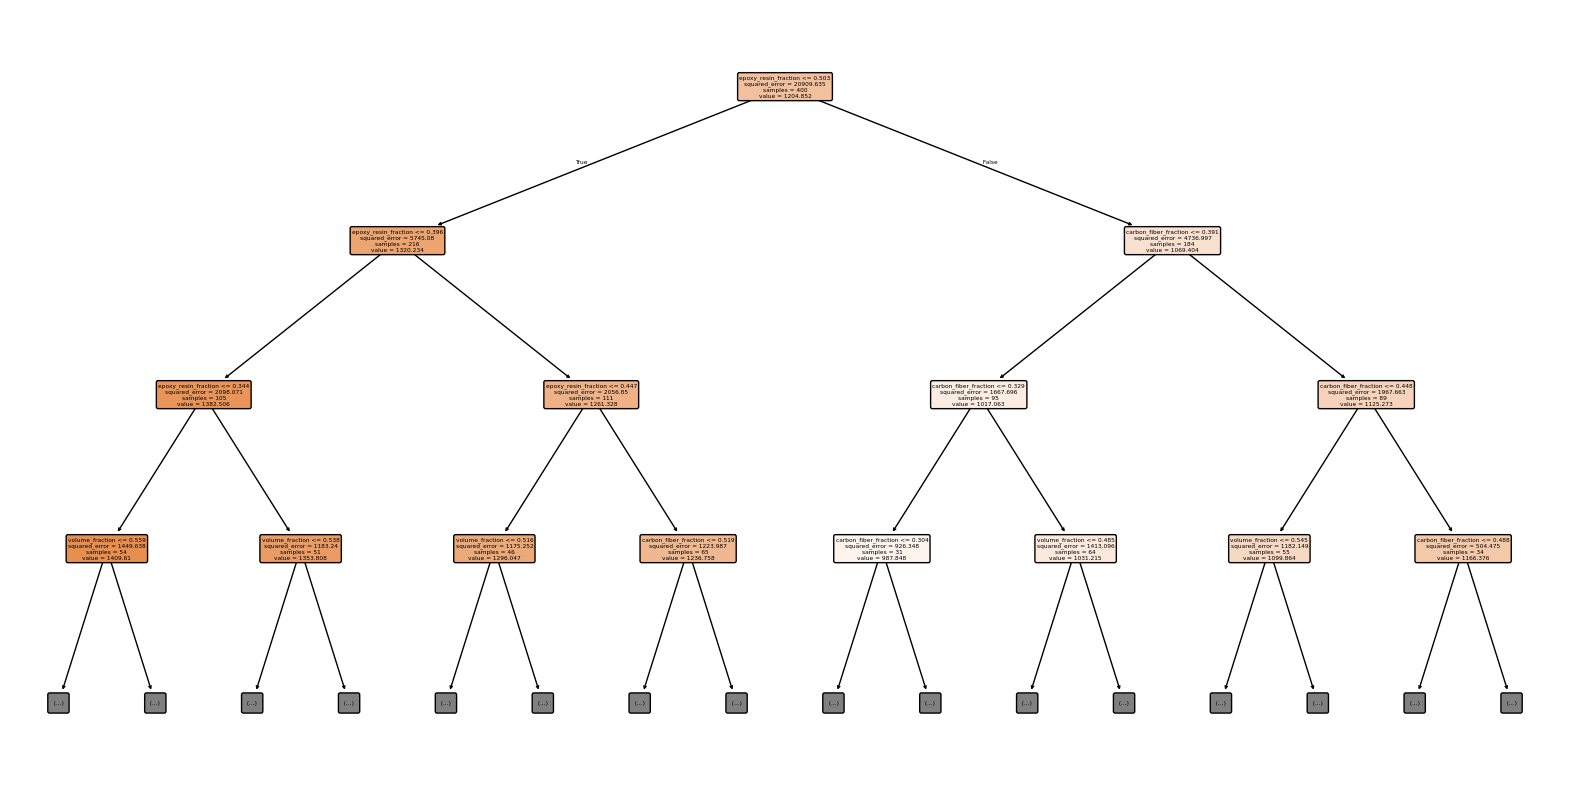

In [11]:
# 6. Visualize the Tree Structure
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, filled=True, rounded=True, max_depth=3)
plt.show()

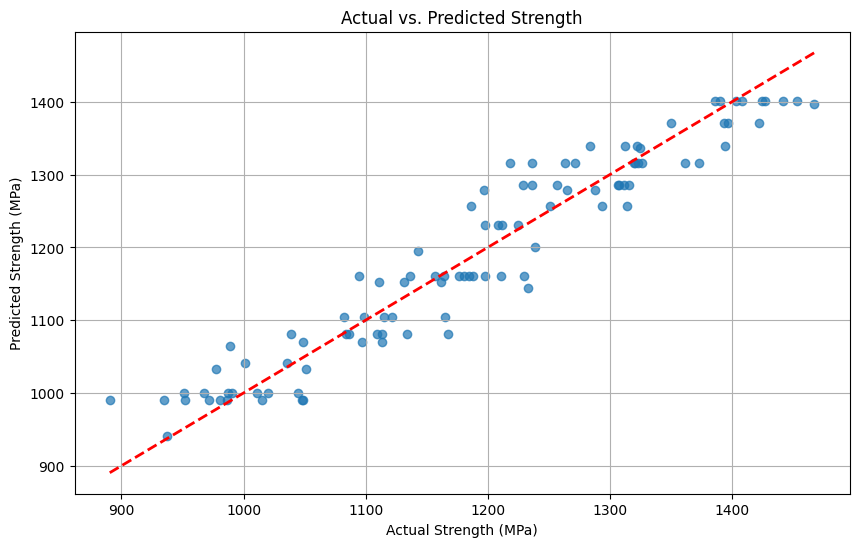

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Actual vs. Predicted Strength')
plt.grid(True)
plt.show()

In [13]:
# 7. Calculate Feature Importance
feature_importances = dt_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

Feature Importances:
                 Feature  Importance
1   epoxy_resin_fraction    0.890240
0  carbon_fiber_fraction    0.089339
2        volume_fraction    0.020420


### 8. Tune `max_depth` to mitigate overfitting

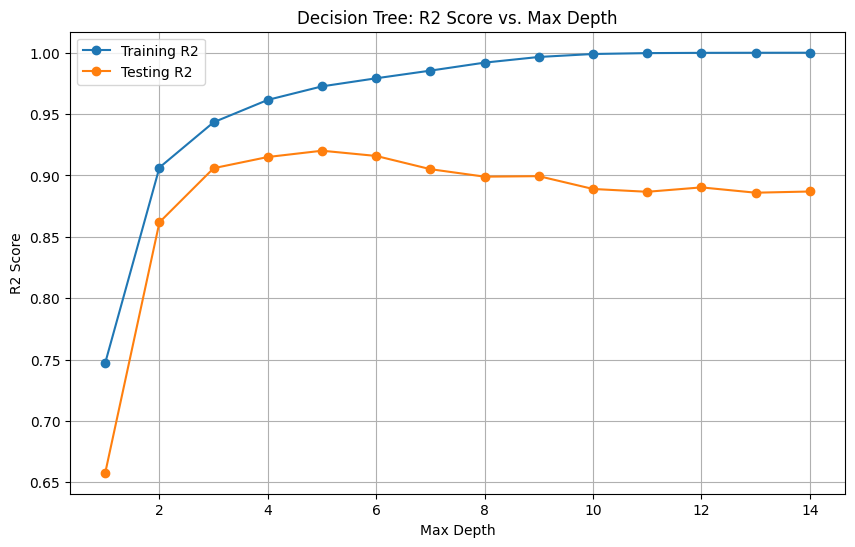

In [14]:
max_depths = range(1, 15) # Explore max_depth from 1 to 14
train_r2_scores = []
test_r2_scores = []

for depth in max_depths:
    dt_tuned_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_tuned_model.fit(X_train, y_train)

    y_train_pred = dt_tuned_model.predict(X_train)
    y_test_pred = dt_tuned_model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_r2_scores, label='Training R2', marker='o')
plt.plot(max_depths, test_r2_scores, label='Testing R2', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('R2 Score')
plt.title('Decision Tree: R2 Score vs. Max Depth')
plt.legend()
plt.grid(True)
plt.show()

The plot above shows how the R2 score changes for both the training and testing sets as `max_depth` increases. We are looking for the point where the test R2 score starts to plateau or decrease while the training R2 score continues to increase significantly, which indicates overfitting. A good `max_depth` would be where the test R2 score is highest or where there's a good balance between training and testing performance without a large gap.

### 9. Calculate Cross-Validation Scores

In [15]:
from sklearn.model_selection import cross_val_score

# The dt_model is already defined with max_depth=5
cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='r2')

print(f"Cross-validation R2 scores: {cv_scores}")
print(f"Mean CV R2 score: {cv_scores.mean():.4f}")
print(f"Standard deviation of CV R2 scores: {cv_scores.std():.4f}")

Cross-validation R2 scores: [0.92465135 0.94181026 0.93344993 0.93109267 0.95355841]
Mean CV R2 score: 0.9369
Standard deviation of CV R2 scores: 0.0100


### 10. Compare with Random Forest Regressor

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train a Random Forest Regressor
# Using the same random_state for reproducibility
# n_estimators is the number of trees in the forest
# max_depth can be tuned, but starting with a reasonable value or letting it grow
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest performance
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"\nRandom Forest Regressor Performance (max_depth=5, n_estimators=100):")
print(f"R2 Score: {r2_rf:.4f}")
print(f"MAE: {mae_rf:.2f} MPa")
print(f"RMSE: {rmse_rf:.2f} MPa")

print(f"\nDecision Tree Regressor Performance (max_depth=5):")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} MPa")
print(f"RMSE: {rmse:.2f} MPa")


Random Forest Regressor Performance (max_depth=5, n_estimators=100):
R2 Score: 0.9375
MAE: 29.23 MPa
RMSE: 36.16 MPa

Decision Tree Regressor Performance (max_depth=5):
R2 Score: 0.9202
MAE: 33.19 MPa
RMSE: 40.86 MPa
